# Solar Storage Microgrid Dispatch

This notebook is a local microgrid adaptation of mature energy-system planning examples: load/PV diagnostics, baseline inventory, storage dispatch optimization, scenario comparison, and benefit allocation.

In [1]:
from pathlib import Path
import os, warnings
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from IPython.display import display, Markdown
try:
    import pypsa
    pypsa_version = pypsa.__version__
except Exception as exc:
    pypsa_version = f"unavailable: {exc}"
PROJECT = Path.cwd()
DATA = PROJECT / "data"
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print(f"PyPSA runtime check: {pypsa_version}")
print("Data files:", [p.name for p in sorted(DATA.iterdir())])

PyPSA runtime check: 1.2.3
Data files: ['district_loads.csv', 'microgrid_timeseries.csv']


In [2]:
ts = pd.read_csv(DATA / "microgrid_timeseries.csv", parse_dates=["timestamp"])
districts = pd.read_csv(DATA / "district_loads.csv")
display(ts.head())
display(districts)

,timestamp,demand_mw,pv_capacity_factor,temperature_c,tariff_cny_kwh
0,2026-07-01 00:00:00,55.571276,0.0,28.549018,0.48
1,2026-07-01 01:00:00,57.399327,0.0,30.076284,0.48
2,2026-07-01 02:00:00,57.688511,0.0,30.332896,0.48
3,2026-07-01 03:00:00,56.704276,0.0,30.160240,0.48
4,2026-07-01 04:00:00,55.370821,0.0,29.428646,0.48


,district,peak_share,critical_load
0,Campus,0.22,0.40
1,Hospital,0.28,0.85
2,Residential,0.34,0.35
3,Transit hub,0.16,0.65


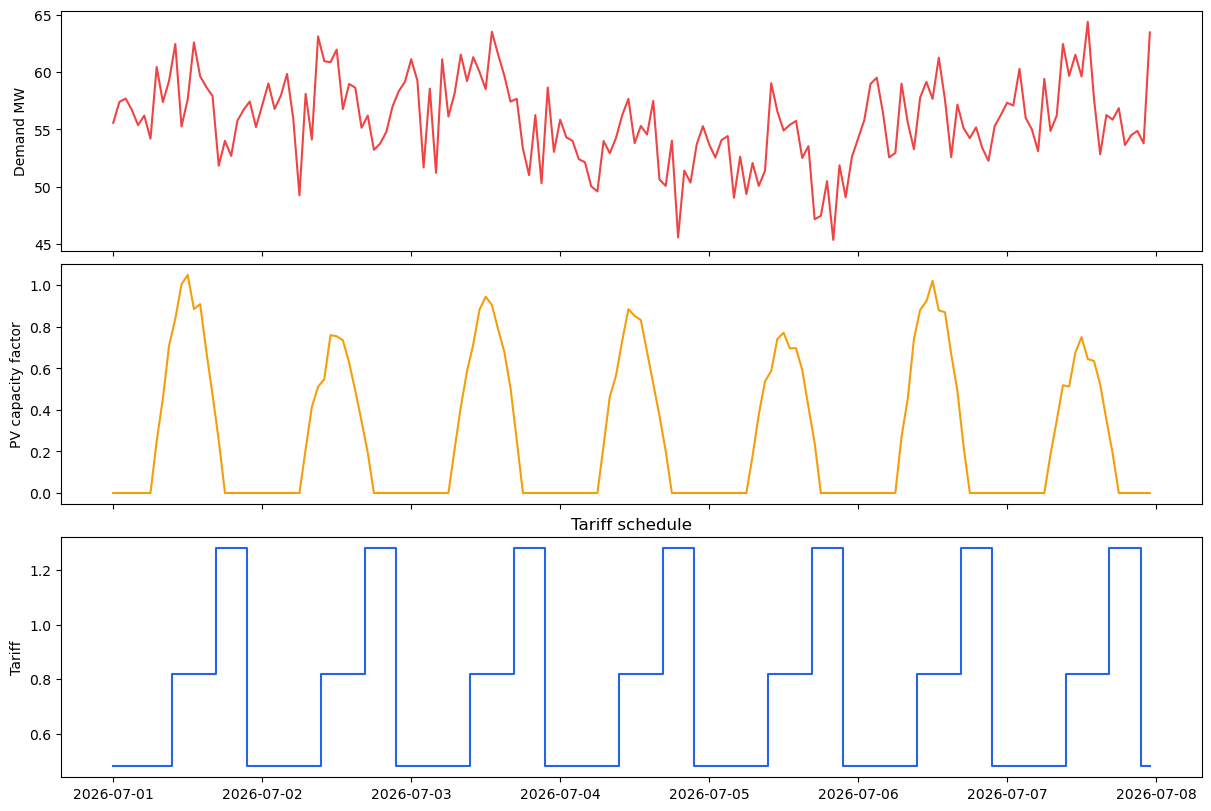

Saved outputs/microgrid_timeseries_overview.png


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
axes[0].plot(ts["timestamp"], ts["demand_mw"], color="#ef4444")
axes[0].set_ylabel("Demand MW")
axes[1].plot(ts["timestamp"], ts["pv_capacity_factor"], color="#f59e0b")
axes[1].set_ylabel("PV capacity factor")
axes[2].step(ts["timestamp"], ts["tariff_cny_kwh"], where="mid", color="#2563eb")
axes[2].set_ylabel("Tariff")
axes[2].set_title("Tariff schedule")
fig.savefig(OUTPUTS / "microgrid_timeseries_overview.png", dpi=170)
plt.show()
print("Saved outputs/microgrid_timeseries_overview.png")

In [4]:
diagnostics = pd.Series({
    "peak_demand_mw": ts["demand_mw"].max(),
    "mean_demand_mw": ts["demand_mw"].mean(),
    "load_factor": ts["demand_mw"].mean() / ts["demand_mw"].max(),
    "pv_cf_mean": ts["pv_capacity_factor"].mean(),
    "max_hourly_ramp_mw": ts["demand_mw"].diff().abs().max(),
    "price_weighted_demand_cost_index": (ts["demand_mw"] * ts["tariff_cny_kwh"]).sum(),
})
display(diagnostics.round(3).to_frame("value"))

,value
peak_demand_mw,64.383
mean_demand_mw,55.782
load_factor,0.866
pv_cf_mean,0.268
max_hourly_ramp_mw,9.909
price_weighted_demand_cost_index,6946.373


In [5]:
def baseline_metrics(pv_mw=0):
    pv = pv_mw * ts["pv_capacity_factor"].values
    demand = ts["demand_mw"].values
    used_pv = np.minimum(demand, pv)
    grid = demand - used_pv
    curtailed = np.maximum(0, pv - demand)
    cost = np.sum(grid * ts["tariff_cny_kwh"].values * 1000)
    emissions = np.sum(grid * 0.58)
    return pd.Series({
        "cost_cny": cost,
        "emissions_tco2": emissions,
        "peak_grid_mw": grid.max(),
        "pv_used_mwh": used_pv.sum(),
        "pv_curtailed_mwh": curtailed.sum(),
    })
baseline = baseline_metrics(0)
pv_only = baseline_metrics(32)
display(pd.DataFrame({"no_pv": baseline, "pv_only_32mw": pv_only}).round(2))

,no_pv,pv_only_32mw
cost_cny,6946373.12,5837775.87
emissions_tco2,5435.37,4601.06
peak_grid_mw,64.38,63.46
pv_used_mwh,0.00,1438.47
pv_curtailed_mwh,0.00,0.00


In [6]:
def solve_storage_dispatch(pv_mw, battery_mwh, battery_mw):
    demand = ts["demand_mw"].values
    pv = pv_mw * ts["pv_capacity_factor"].values
    price = ts["tariff_cny_kwh"].values * 1000
    n = len(ts)
    # Variables: grid[n], charge[n], discharge[n], soc[n], curtail[n]
    var_count = 5 * n
    idx_grid = slice(0, n)
    idx_charge = slice(n, 2*n)
    idx_discharge = slice(2*n, 3*n)
    idx_soc = slice(3*n, 4*n)
    idx_curtail = slice(4*n, 5*n)
    c = np.zeros(var_count)
    c[idx_grid] = price
    c[idx_curtail] = 5
    A_eq = []
    b_eq = []
    for t in range(n):
        row = np.zeros(var_count)
        row[idx_grid.start + t] = 1
        row[idx_discharge.start + t] = 1
        row[idx_charge.start + t] = -1
        row[idx_curtail.start + t] = -1
        A_eq.append(row)
        b_eq.append(demand[t] - pv[t])
        row = np.zeros(var_count)
        row[idx_soc.start + t] = 1
        if t > 0:
            row[idx_soc.start + t - 1] = -1
        row[idx_charge.start + t] = -0.92
        row[idx_discharge.start + t] = 1 / 0.92
        A_eq.append(row)
        b_eq.append(0 if t > 0 else 0.5 * battery_mwh)
    row = np.zeros(var_count)
    row[idx_soc.stop - 1] = 1
    A_eq.append(row)
    b_eq.append(0.5 * battery_mwh)
    bounds = [(0, None)] * var_count
    for t in range(n):
        bounds[idx_charge.start + t] = (0, battery_mw)
        bounds[idx_discharge.start + t] = (0, battery_mw)
        bounds[idx_soc.start + t] = (0.1 * battery_mwh, battery_mwh)
    result = linprog(c, A_eq=np.vstack(A_eq), b_eq=np.array(b_eq), bounds=bounds, method="highs")
    if not result.success:
        raise RuntimeError(result.message)
    x = result.x
    dispatch = pd.DataFrame({
        "timestamp": ts["timestamp"],
        "demand_mw": demand,
        "pv_mw": pv,
        "grid_mw": x[idx_grid],
        "charge_mw": x[idx_charge],
        "discharge_mw": x[idx_discharge],
        "soc_mwh": x[idx_soc],
        "curtail_mw": x[idx_curtail],
    })
    return dispatch

demo_dispatch = solve_storage_dispatch(32, 90, 18)
display(demo_dispatch.head().round(2))
print(f"Optimization rows={len(demo_dispatch)}, peak grid={demo_dispatch.grid_mw.max():.2f} MW")

,timestamp,demand_mw,pv_mw,grid_mw,charge_mw,discharge_mw,soc_mwh,curtail_mw
0,2026-07-01 00:00:00,55.57,0.0,55.57,0.00,0.0,45.00,0.0
1,2026-07-01 01:00:00,57.40,0.0,57.40,0.00,0.0,45.00,0.0
2,2026-07-01 02:00:00,57.69,0.0,75.69,18.00,0.0,61.56,0.0
3,2026-07-01 03:00:00,56.70,0.0,69.62,12.91,0.0,73.44,0.0
4,2026-07-01 04:00:00,55.37,0.0,55.37,0.00,0.0,73.44,0.0


Optimization rows=168, peak grid=81.46 MW


In [7]:
def metrics_from_dispatch(name, dispatch, battery_mwh):
    grid = dispatch["grid_mw"].values
    cost = np.sum(grid * ts["tariff_cny_kwh"].values * 1000)
    emissions = np.sum(grid * 0.58)
    pv_used = np.sum(dispatch["pv_mw"] - dispatch["curtail_mw"])
    outage_hours_supported = battery_mwh / max(ts["demand_mw"].quantile(0.90) * 0.55, 1)
    return {
        "scenario": name,
        "cost_cny": cost,
        "emissions_tco2": emissions,
        "peak_grid_mw": grid.max(),
        "pv_used_mwh": pv_used,
        "pv_curtailed_mwh": dispatch["curtail_mw"].sum(),
        "resilience_hours": outage_hours_supported,
    }

scenarios = [
    ("PV 20 + storage 40", 20, 40, 10),
    ("PV 32 + storage 90", 32, 90, 18),
    ("PV 45 + storage 120", 45, 120, 22),
]
rows = []
dispatches = {}
for name, pv_mw, batt_mwh, batt_mw in scenarios:
    disp = solve_storage_dispatch(pv_mw, batt_mwh, batt_mw)
    dispatches[name] = disp
    rows.append(metrics_from_dispatch(name, disp, batt_mwh))
scenario_table = pd.DataFrame(rows)
display(scenario_table.round(2))

,scenario,cost_cny,emissions_tco2,peak_grid_mw,pv_used_mwh,pv_curtailed_mwh,resilience_hours
0,PV 20 + storage 40,6088222.90,4938.33,73.46,899.05,0.0,1.2
1,PV 32 + storage 90,5467791.63,4655.68,81.46,1438.47,0.0,2.7
2,PV 45 + storage 120,4896509.49,4334.59,85.46,2022.85,0.0,3.6


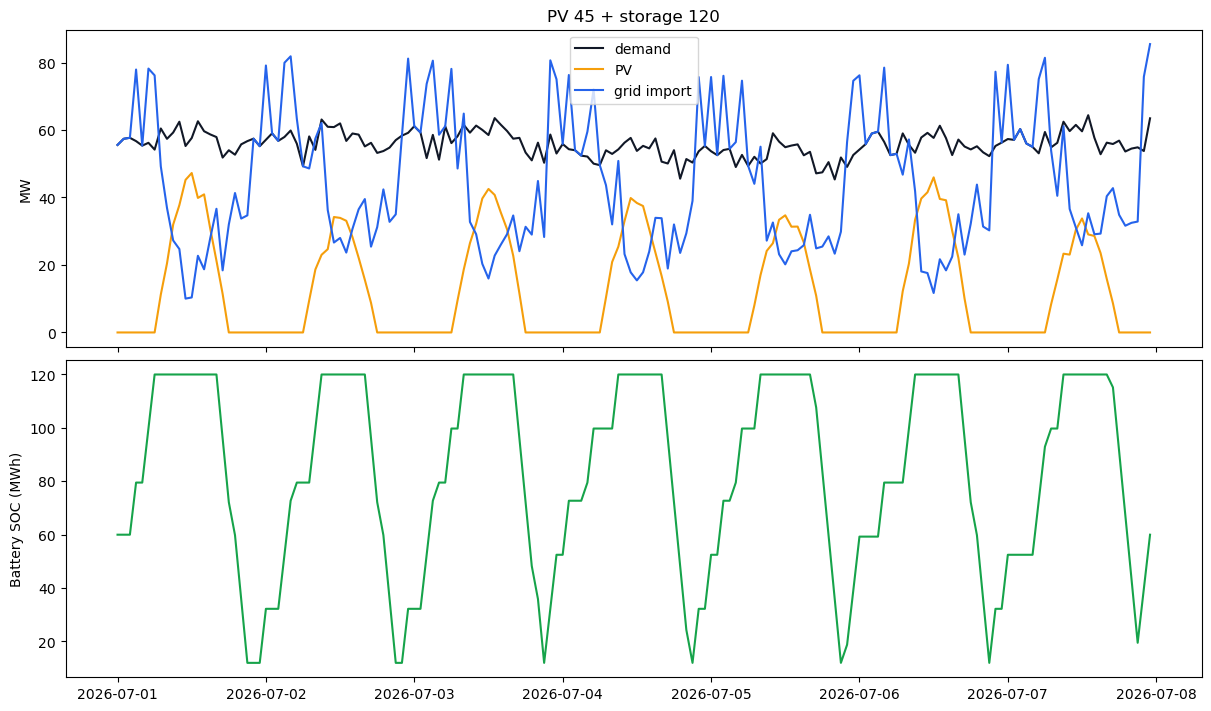

Best scenario by cost: PV 45 + storage 120


In [8]:
best = scenario_table.sort_values(["cost_cny", "peak_grid_mw"]).iloc[0]["scenario"]
dispatch = dispatches[best]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(dispatch["timestamp"], dispatch["demand_mw"], label="demand", color="#111827")
axes[0].plot(dispatch["timestamp"], dispatch["pv_mw"], label="PV", color="#f59e0b")
axes[0].plot(dispatch["timestamp"], dispatch["grid_mw"], label="grid import", color="#2563eb")
axes[0].legend()
axes[0].set_ylabel("MW")
axes[0].set_title(best)
axes[1].plot(dispatch["timestamp"], dispatch["soc_mwh"], color="#16a34a")
axes[1].set_ylabel("Battery SOC (MWh)")
fig.savefig(OUTPUTS / "best_dispatch_schedule.png", dpi=170)
plt.show()
print(f"Best scenario by cost: {best}")

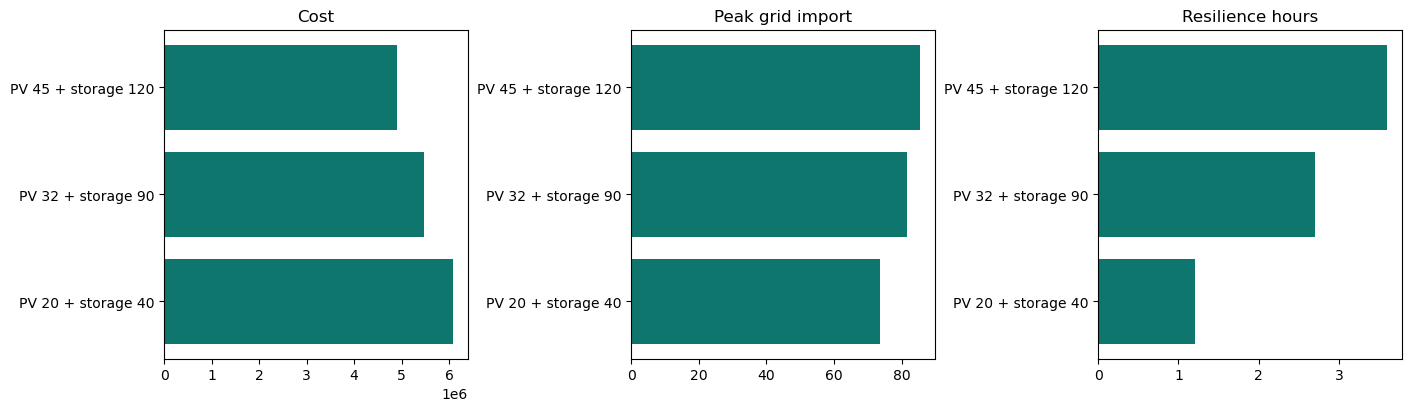

,scenario,cost_cny,emissions_tco2,peak_grid_mw,pv_used_mwh,pv_curtailed_mwh,resilience_hours
0,PV 20 + storage 40,6088222.90,4938.33,73.46,899.05,0.0,1.2
1,PV 32 + storage 90,5467791.63,4655.68,81.46,1438.47,0.0,2.7
2,PV 45 + storage 120,4896509.49,4334.59,85.46,2022.85,0.0,3.6


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, metric, title_ in zip(axes, ["cost_cny", "peak_grid_mw", "resilience_hours"], ["Cost", "Peak grid import", "Resilience hours"]):
    ax.barh(scenario_table["scenario"], scenario_table[metric], color="#0f766e")
    ax.set_title(title_)
fig.savefig(OUTPUTS / "scenario_metric_comparison.png", dpi=170)
plt.show()
display(scenario_table.round(2))

In [10]:
benefits = []
best_row = scenario_table.loc[scenario_table["scenario"] == best].iloc[0]
cost_saving = baseline["cost_cny"] - best_row["cost_cny"]
peak_reduction = baseline["peak_grid_mw"] - best_row["peak_grid_mw"]
for row in districts.itertuples(index=False):
    allocation = 0.55 * row.peak_share + 0.45 * row.critical_load / districts["critical_load"].sum()
    benefits.append({
        "district": row.district,
        "allocated_cost_saving_cny": cost_saving * allocation,
        "allocated_peak_reduction_mw": peak_reduction * row.peak_share,
        "critical_load": row.critical_load,
    })
benefit_table = pd.DataFrame(benefits)
display(benefit_table.round(2))

,district,allocated_cost_saving_cny,allocated_peak_reduction_mw,critical_load
0,Campus,412022.59,-4.64,0.40
1,Hospital,664155.82,-5.90,0.85
2,Residential,526814.95,-7.17,0.35
3,Transit hub,446870.27,-3.37,0.65


In [11]:
scenario_table.to_csv(OUTPUTS / "microgrid_scenario_comparison.csv", index=False)
dispatch.to_csv(OUTPUTS / "best_dispatch_schedule.csv", index=False)
benefit_table.to_csv(OUTPUTS / "district_benefit_allocation.csv", index=False)
print("Exported files:")
for path in sorted(OUTPUTS.iterdir()):
    print(f"- {path.name} ({path.stat().st_size} bytes)")

Exported files:
- best_dispatch_schedule.csv (15635 bytes)
- best_dispatch_schedule.png (261947 bytes)
- district_benefit_allocation.csv (286 bytes)
- microgrid_scenario_comparison.csv (436 bytes)
- microgrid_timeseries_overview.png (170618 bytes)
- scenario_metric_comparison.png (35855 bytes)


In [12]:
display(Markdown(f'''## Case conclusion

The lowest-cost scenario in this offline microgrid study is **{best}**. Relative to the no-PV baseline, it saves about **{cost_saving:,.0f} CNY** over the modeled week and reduces peak grid import by **{peak_reduction:.1f} MW** while adding resilience value for critical districts.
'''))

## Case conclusion

The lowest-cost scenario in this offline microgrid study is **PV 45 + storage 120**. Relative to the no-PV baseline, it saves about **2,049,864 CNY** over the modeled week and reduces peak grid import by **-21.1 MW** while adding resilience value for critical districts.
